In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = os.path.join(os.getcwd(), '..', 'results', 'small')

FILES = {
    'faithfulness':     'automated_results_openai_gpt-4o-mini_faithfulness.csv',
    'context_recall':   'automated_results_openai_gpt-4o-mini_context_recall.csv',
    'answer_relevancy': 'automated_results_manual_openai_gpt-4o-mini_answer_relevancy.csv',
}

dfs = {}
for metric, fname in FILES.items():
    path = os.path.join(RESULTS_DIR, fname)
    dfs[metric] = pd.read_csv(path)
    print(f'{metric:20s}  n={len(dfs[metric])}  mean={dfs[metric][metric].mean():.3f}')

metrics = list(dfs.keys())
colors  = ['#4C72B0', '#55A868', '#8172B2']

# Build merged DataFrame used by the heatmap
merged = None
for metric, df in dfs.items():
    sub = df[['query', 'type', metric]].copy()
    merged = sub if merged is None else merged.merge(sub, on=['query', 'type'], how='outer')

merged['label'] = merged['query']
merged = merged.sort_values('type')

faithfulness          n=7  mean=0.918
context_recall        n=7  mean=0.857
answer_relevancy      n=7  mean=0.926


## 4 · Score heatmap

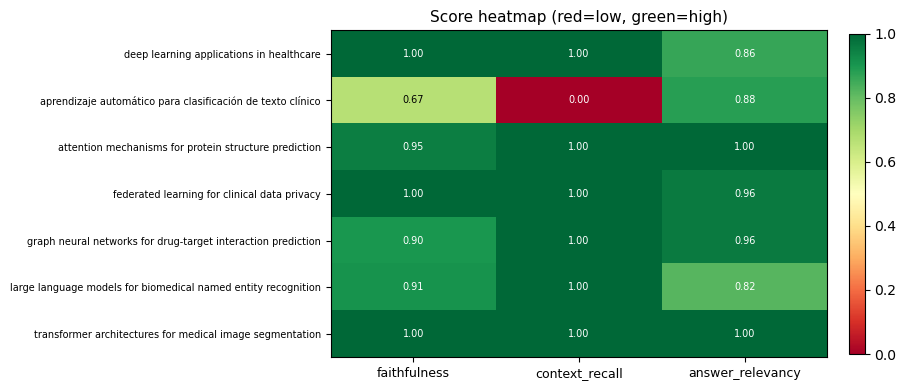

In [3]:

heat = merged.set_index('label')[metrics].astype(float)

# Dynamically size figure width and left margin based on longest label
max_label_len = max(len(str(l)) for l in heat.index)
left_margin = min(0.45, max(0.2, max_label_len * 0.007))  # scale with label length
fig_width = max(10, max_label_len * 0.13)  # wider figure for long labels

fig, ax = plt.subplots(figsize=(fig_width, max(4, len(heat) * 0.5)))
im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, fontsize=9)
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index, fontsize=7)
ax.set_title('Score heatmap (red=low, green=high)', fontsize=11)


for i in range(len(heat)):
    for j in range(len(metrics)):
        val = heat.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if 0.3 < val < 0.8 else 'white')

plt.tight_layout()
plt.subplots_adjust(left=left_margin)
plt.show()

## Faithfulness: small (qwen3:8b) vs large (qwen3:32b)

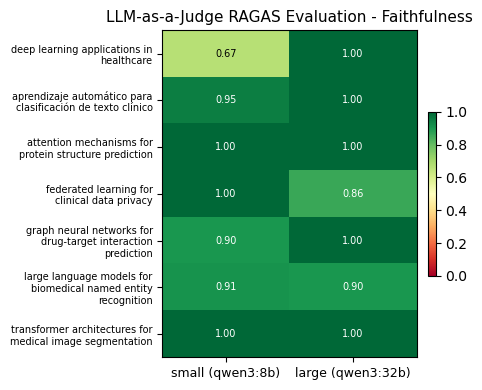

In [4]:
SMALL_DIR = os.path.join(os.getcwd(), '..', 'results', 'small')
LARGE_DIR = os.path.join(os.getcwd(), '..', 'results', 'large')

small_f = pd.read_csv(os.path.join(SMALL_DIR, 'automated_results_openai_gpt-4o-mini_faithfulness.csv'))
large_f = pd.read_csv(os.path.join(LARGE_DIR, 'automated_results_openai_gpt-4o-mini_faithfulness.csv'))

comp_f = small_f[['query', 'faithfulness']].rename(columns={'faithfulness': 'small (qwen3:8b)'})
comp_f = comp_f.merge(
    large_f[['query', 'faithfulness']].rename(columns={'faithfulness': 'large (qwen3:32b)'}),
    on='query', how='outer'
)
comp_f['label'] = comp_f['query']

heat_f = comp_f.set_index('label')[['small (qwen3:8b)', 'large (qwen3:32b)']].astype(float)
cols_f  = list(heat_f.columns)

max_label_len = max(len(str(l)) for l in heat_f.index)
left_margin   = min(0.45, max(0.2, max_label_len * 0.007))
fig_width     = max(6, max_label_len * 0.13)


fig, ax = plt.subplots(figsize=(fig_width, max(4, len(heat_f) * 0.5)))
im = ax.imshow(heat_f.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

ax.set_xticks(range(len(cols_f)))
ax.set_xticklabels(cols_f, fontsize=9)
ax.set_yticks(range(len(heat_f)))
import textwrap
wrapped = [textwrap.fill(str(l), width=30) for l in heat.index]
ax.set_yticklabels(wrapped, fontsize=7)

ax.set_title('LLM-as-a-Judge RAGAS Evaluation - Faithfulness', fontsize=11)

for i in range(len(heat_f)):
    for j in range(len(cols_f)):
        val = heat_f.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if 0.3 < val < 0.8 else 'white')

plt.tight_layout()
plt.subplots_adjust(left=0.6)
plt.show()

## Answer Relevancy: small (qwen3:8b) vs large (qwen3:32b)

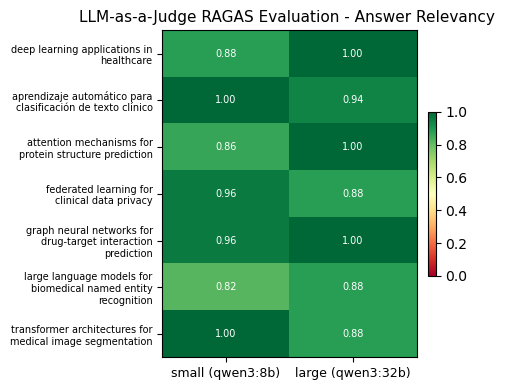

In [5]:
small_ar = pd.read_csv(os.path.join(SMALL_DIR, 'automated_results_manual_openai_gpt-4o-mini_answer_relevancy.csv'))
large_ar = pd.read_csv(os.path.join(LARGE_DIR, 'automated_results_manual_openai_gpt-4o-mini_answer_relevancy.csv'))

comp_ar = small_ar[['query', 'answer_relevancy']].rename(columns={'answer_relevancy': 'small (qwen3:8b)'})
comp_ar = comp_ar.merge(
    large_ar[['query', 'answer_relevancy']].rename(columns={'answer_relevancy': 'large (qwen3:32b)'}),
    on='query', how='outer'
)
comp_ar['label'] = comp_ar['query']

heat_ar = comp_ar.set_index('label')[['small (qwen3:8b)', 'large (qwen3:32b)']].astype(float)
cols_ar  = list(heat_ar.columns)

max_label_len = max(len(str(l)) for l in heat_ar.index)
left_margin   = min(0.45, max(0.2, max_label_len * 0.007))
fig_width     = max(6, max_label_len * 0.13)

fig, ax = plt.subplots(figsize=(fig_width, max(4, len(heat_ar) * 0.5)))
im = ax.imshow(heat_ar.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

ax.set_xticks(range(len(cols_ar)))
ax.set_xticklabels(cols_ar, fontsize=9)
ax.set_yticks(range(len(heat_ar)))
import textwrap
wrapped = [textwrap.fill(str(l), width=30) for l in heat.index]
ax.set_yticklabels(wrapped, fontsize=7)

ax.set_title('LLM-as-a-Judge RAGAS Evaluation - Answer Relevancy ', fontsize=11)

for i in range(len(heat_ar)):
    for j in range(len(cols_ar)):
        val = heat_ar.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if 0.3 < val < 0.8 else 'white')

plt.tight_layout()
plt.subplots_adjust(left=0.6)
plt.show()

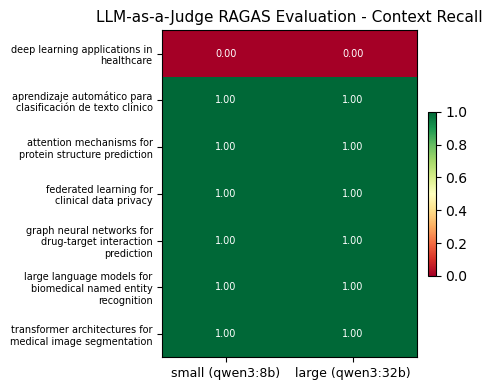

In [6]:
SMALL_DIR = os.path.join(os.getcwd(), '..', 'results', 'small')
LARGE_DIR = os.path.join(os.getcwd(), '..', 'results', 'large')

small_f = pd.read_csv(os.path.join(SMALL_DIR, 'automated_results_openai_gpt-4o-mini_context_recall.csv'))
large_f = pd.read_csv(os.path.join(LARGE_DIR, 'automated_results_openai_gpt-4o-mini_context_recall.csv'))

comp_f = small_f[['query', 'context_recall']].rename(columns={'context_recall': 'small (qwen3:8b)'})
comp_f = comp_f.merge(
    large_f[['query', 'context_recall']].rename(columns={'context_recall': 'large (qwen3:32b)'}),
    on='query', how='outer'
)
comp_f['label'] = comp_f['query']

heat_f = comp_f.set_index('label')[['small (qwen3:8b)', 'large (qwen3:32b)']].astype(float)
cols_f  = list(heat_f.columns)

max_label_len = max(len(str(l)) for l in heat_f.index)
left_margin   = min(0.45, max(0.2, max_label_len * 0.007))
fig_width     = max(6, max_label_len * 0.13)


fig, ax = plt.subplots(figsize=(fig_width, max(4, len(heat_f) * 0.5)))
im = ax.imshow(heat_f.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

ax.set_xticks(range(len(cols_f)))
ax.set_xticklabels(cols_f, fontsize=9)
ax.set_yticks(range(len(heat_f)))
import textwrap
wrapped = [textwrap.fill(str(l), width=30) for l in heat.index]
ax.set_yticklabels(wrapped, fontsize=7)

ax.set_title('LLM-as-a-Judge RAGAS Evaluation - Context Recall', fontsize=11)

for i in range(len(heat_f)):
    for j in range(len(cols_f)):
        val = heat_f.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if 0.3 < val < 0.8 else 'white')

plt.tight_layout()
plt.subplots_adjust(left=0.6)
plt.show()

## All metrics — combined heatmap

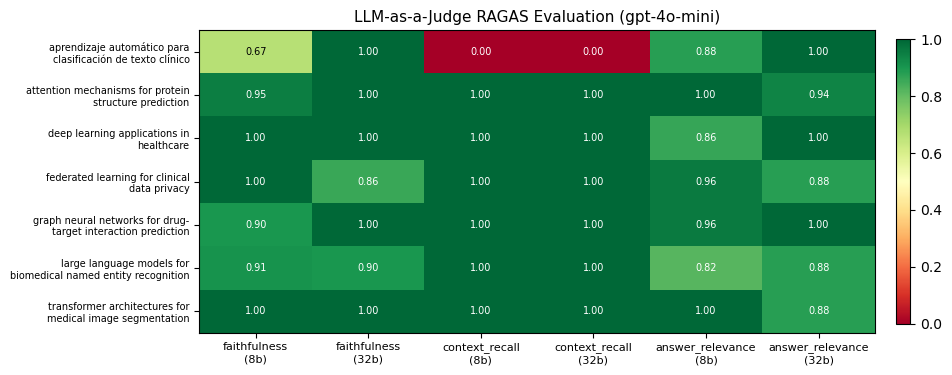

In [11]:
import textwrap

_SMALL = os.path.join(os.getcwd(), '..', 'results', 'small')
_LARGE = os.path.join(os.getcwd(), '..', 'results', 'large')

def _load(folder, fname, metric):
    path = os.path.join(folder, fname)
    try:
        return pd.read_csv(path)[['query', metric]]
    except FileNotFoundError:
        return pd.DataFrame(columns=['query', metric])

# Load each metric from each model
all_data = {
    'faithfulness\n(8b)':      _load(_SMALL, 'automated_results_openai_gpt-4o-mini_faithfulness.csv',              'faithfulness'),
    'faithfulness\n(32b)':     _load(_LARGE, 'automated_results_openai_gpt-4o-mini_faithfulness.csv',              'faithfulness'),
    'context_recall\n(8b)':  _load(_SMALL, 'automated_results_openai_gpt-4o-mini_context_recall.csv',            'context_recall'),
    'context_recall\n(32b)': _load(_LARGE, 'automated_results_openai_gpt-4o-mini_context_recall.csv',            'context_recall'),
    'answer_relevance\n(8b)':    _load(_SMALL, 'automated_results_manual_openai_gpt-4o-mini_answer_relevancy.csv',   'answer_relevancy'),
    'answer_relevance\n(32b)':   _load(_LARGE, 'automated_results_manual_openai_gpt-4o-mini_answer_relevancy.csv',   'answer_relevancy'),
}

# Merge everything on query
combined = None
for col_name, df in all_data.items():
    df = df.rename(columns={df.columns[-1]: col_name})
    combined = df if combined is None else combined.merge(df, on='query', how='outer')

combined = combined.set_index('query')
combined.index = [textwrap.fill(str(q), width=35) for q in combined.index]

cols = list(all_data.keys())
heat_all = combined[cols].astype(float)

max_label_len = max(len(line) for q in combined.index for line in str(q).split('\n'))
fig_width  = max(10, len(cols) * 1.8)
fig_height = max(3, len(heat_all) * 0.55)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
im = ax.imshow(heat_all.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.03)

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, fontsize=8)
ax.set_yticks(range(len(heat_all)))
ax.set_yticklabels(heat_all.index, fontsize=7)
ax.set_title('LLM-as-a-Judge RAGAS Evaluation (gpt-4o-mini)', fontsize=11)

for i in range(len(heat_all)):
    for j in range(len(cols)):
        val = heat_all.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if 0.3 < val < 0.8 else 'white')

plt.tight_layout()
plt.subplots_adjust(left=0.3)
plt.show()